# toy1 — Pearson correlations

For each metric vs accuracy, plot and compute Pearson *r* on all items.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# accuracy

In [2]:
with open('../8.Accuracy/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

accuracy_data = {}
satisfaction_data = {}
has_code_location = {}
for nfr in data:
    nfr_id = nfr['id']
    llm_response = nfr['llm_response']
    gt_label = nfr['satisfaction_level'].lower()
    if gt_label == 'satisfied':
        gt = 4
    elif gt_label == 'weakly satisfied':
        gt = 3
    elif gt_label == 'weakly denied':
        gt = 2
    elif gt_label == 'denied':
        gt = 1
    else:
        raise Exception(nfr_id)
    accuracy_data[nfr_id] = 1 - abs(gt - llm_response) / 3
    satisfaction_data[nfr_id] = nfr['satisfaction_level']
    locs = nfr.get('code_location') or []
    has_code_location[nfr_id] = len(locs) > 0

# complexity

In [3]:
with open('../4.NFRComplexity/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

complexity_data = {}
for nfr in data:
    complexity_data[nfr['id']] = nfr['complexity']

# tracability

In [4]:
with open('../6.NFRTracability/data-tracability.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

locc_data = {}
cdc_data = {}
cdo_data = {}
docs_data = {}
docm_data = {}
for nfr in data:
    nfr_id = nfr['id']
    locc_data[nfr_id] = nfr['locc']
    cdc_data[nfr_id] = nfr['cdc']
    cdo_data[nfr_id] = nfr['cdo']
    docs_data[nfr_id] = nfr['docs']
    docm_data[nfr_id] = nfr['docm']

# ambiguity

In [5]:
with open('../14.ambiguity_again/second round/data_resolved.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

lexical_data = {}
syntactic_data = {}
semantic_data = {}
vagueness_data = {}
incompleteness_data = {}
referential_data = {}
ambiguity_exists_data = {}
sum_ambiguity_data = {}
sum_ambiguity_only_incomplete_and_vague_data = {}
ambiguity_only_incomplete_and_vague_exists_data = {}
for nfr in data:
    nfr_id = nfr['id']
    lexical_data[nfr_id] = nfr['Lexical']
    syntactic_data[nfr_id] = nfr['Syntactic']
    semantic_data[nfr_id] = nfr['Semantic']
    vagueness_data[nfr_id] = nfr['Vagueness']
    incompleteness_data[nfr_id] = nfr['Incompleteness']
    referential_data[nfr_id] = nfr['Referential']
    ambiguity_flags = [
        nfr['Lexical'], nfr['Syntactic'], nfr['Semantic'],
        nfr['Vagueness'], nfr['Incompleteness'], nfr['Referential'],
    ]
    ambiguity_exists_data[nfr_id] = any(ambiguity_flags)
    sum_ambiguity_data[nfr_id] = sum(ambiguity_flags)
    sum_ambiguity_only_incomplete_and_vague_data[nfr_id] = ambiguity_flags[3] + ambiguity_flags[4]
    ambiguity_only_incomplete_and_vague_exists_data[nfr_id] = sum_ambiguity_only_incomplete_and_vague_data[nfr_id] > 0

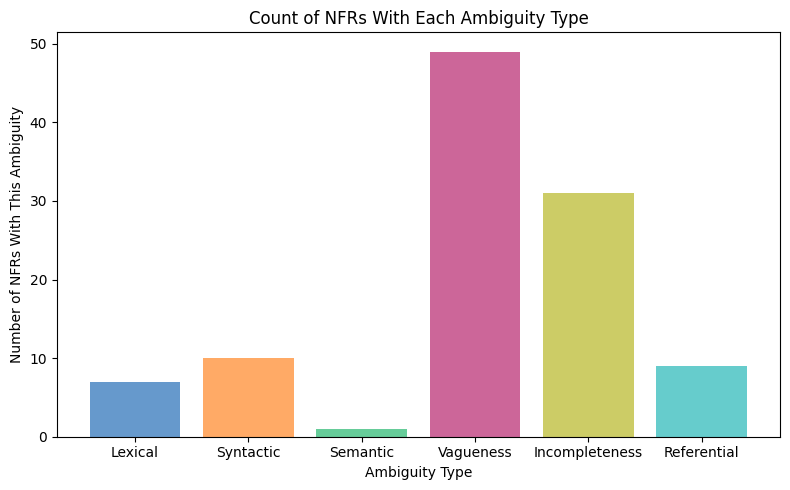

   Ambiguity Type  NFR Count
0         Lexical          7
1       Syntactic         10
2        Semantic          1
3       Vagueness         49
4  Incompleteness         31
5     Referential          9


In [6]:
import matplotlib.pyplot as plt

ambiguity_counts = {
    'Lexical': sum(lexical_data.values()),
    'Syntactic': sum(syntactic_data.values()),
    'Semantic': sum(semantic_data.values()),
    'Vagueness': sum(vagueness_data.values()),
    'Incompleteness': sum(incompleteness_data.values()),
    'Referential': sum(referential_data.values()),
}

plt.figure(figsize=(8, 5))
plt.bar(ambiguity_counts.keys(), ambiguity_counts.values(), color=['#6699cc', '#ffaa66', '#66cc99', '#cc6699', '#cccc66', '#66cccc'])
plt.xlabel('Ambiguity Type')
plt.ylabel('Number of NFRs With This Ambiguity')
plt.title('Count of NFRs With Each Ambiguity Type')
plt.tight_layout()
plt.show()

import pandas as pd
ambiguity_counts_df = pd.DataFrame(list(ambiguity_counts.items()), columns=['Ambiguity Type', 'NFR Count'])
print(ambiguity_counts_df)

# relevancy

In [ ]:
with open('../7.NFRRelevancy/prioritized.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

value_pct_data = {}
cost_pct_data = {}
risk_pct_data = {}
priority_data = {}

for nfr in data:
    nfr_id = nfr['id']
    value_pct_data[nfr_id] = nfr['value_pct']
    cost_pct_data[nfr_id] = nfr['cost_pct']
    risk_pct_data[nfr_id] = nfr['risk_pct']
    priority_data[nfr_id] = nfr['priority']


# complexity2 metrics (`data_metrics.json`)

In [7]:
with open('../10.complexity2/data_metrics.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Collect all metric names; skip Entity Coherence (all null in this dataset)
complexity2_metric_names = list(data[0]['metrics'].keys())
complexity2_metric_names = [
    m for m in complexity2_metric_names
    if any(nfr['metrics'].get(m) is not None for nfr in data)
]

complexity2_data = {m: {} for m in complexity2_metric_names}
for nfr in data:
    nfr_id = nfr['id']
    for m in complexity2_metric_names:
        complexity2_data[m][nfr_id] = nfr['metrics'].get(m)

print(f'Loaded {len(complexity2_metric_names)} complexity2 metrics:')
for m in complexity2_metric_names:
    print(' -', m)

Loaded 11 complexity2 metrics:
 - Consensus grade level (Readability)
 - Headings count (Structure)
 - Headings per sentence (Structure)
 - List items count (Structure)
 - Lists per sentence (Structure)
 - SMAO sentences count (Requirements)
 - SMAO sentences % (Requirements)
 - Vague words per sentence (Requirements)
 - Anaphora per sentence (Requirements)
 - Sentence CV (Requirements)
 - CPRE terms per sentence (CPRE)


# combine all

In [ ]:
df = pd.DataFrame({
    'accuracy': accuracy_data,
    'satisfaction': satisfaction_data,
    'has_code_location': has_code_location,
    'complexity': complexity_data,
    'locc': locc_data,
    'cdc': cdc_data,
    'cdo': cdo_data,
    'docs': docs_data,
    'docm': docm_data,
    'lexical': lexical_data,
    'syntactic': syntactic_data,
    'semantic': semantic_data,
    'vagueness': vagueness_data,
    'incompleteness': incompleteness_data,
    'referential': referential_data,
    'ambiguity_exists': ambiguity_exists_data,
    'sum_ambiguity': sum_ambiguity_data,
    'sum_ambiguity_only_incomplete_and_vague': sum_ambiguity_only_incomplete_and_vague_data,
    'ambiguity_only_incomplete_and_vague_exists': ambiguity_only_incomplete_and_vague_exists_data,
    'value_pct': value_pct_data,
    'cost_pct': cost_pct_data,
    'risk_pct': risk_pct_data,
    'priority': priority_data,
})
for m in complexity2_metric_names:
    df[m] = pd.Series(complexity2_data[m])

df.index.name = 'id'
df = df.reset_index()
df['is_denied'] = df['satisfaction'].str.lower() == 'denied'
df.head()

,id,accuracy,satisfaction,has_code_location,complexity,locc,cdc,cdo,docs,docm,...,Headings per sentence (Structure),List items count (Structure),Lists per sentence (Structure),SMAO sentences count (Requirements),SMAO sentences % (Requirements),Vague words per sentence (Requirements),Anaphora per sentence (Requirements),Sentence CV (Requirements),CPRE terms per sentence (CPRE),is_denied
0,1,1.000000,Satisfied,True,1,63,3,4,0.688587,0.627125,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
1,2,1.000000,Satisfied,True,0,23,5,5,0.879017,0.898760,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
2,3,1.000000,Satisfied,True,0,73,2,2,0.968287,0.962191,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
3,4,0.666667,Satisfied,True,0,15,1,2,0.000000,0.960000,...,0.0,0,0.0,0,0.0,0.0,0.0,0.0,1.0,False
4,5,0.666667,Weakly Denied,True,1,13,2,2,0.946746,0.946746,...,0.0,0,0.0,1,100.0,1.0,0.0,0.0,2.0,False


# plot: as-is


=== as-is (n=148) ===
accuracy
0.000000     4
0.333333    22
0.666667    55
1.000000    67
count    148.000000
mean       0.750000
std        0.269023
min        0.000000
25%        0.666667
50%        0.666667
75%        1.000000
max        1.000000



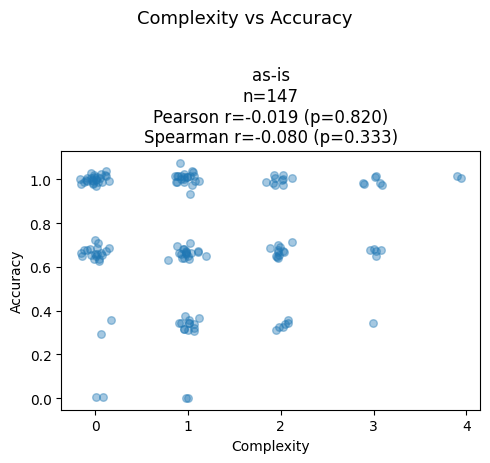

Complexity | as-is: Pearson r=-0.019 (p=0.820), Spearman r=-0.080 (p=0.333), n=147



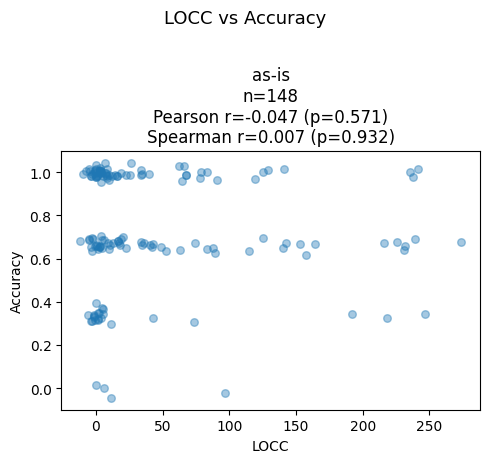

LOCC | as-is: Pearson r=-0.047 (p=0.571), Spearman r=0.007 (p=0.932), n=148



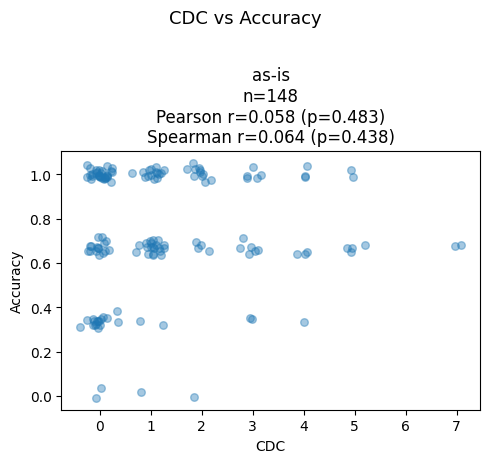

CDC | as-is: Pearson r=0.058 (p=0.483), Spearman r=0.064 (p=0.438), n=148



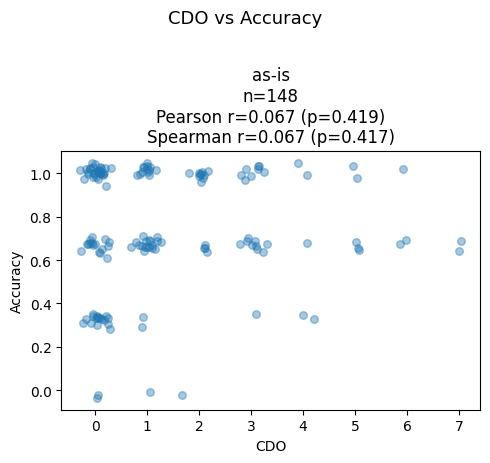

CDO | as-is: Pearson r=0.067 (p=0.419), Spearman r=0.067 (p=0.417), n=148



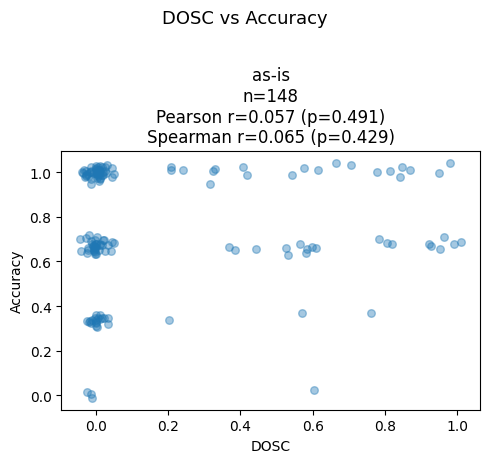

DOSC | as-is: Pearson r=0.057 (p=0.491), Spearman r=0.065 (p=0.429), n=148



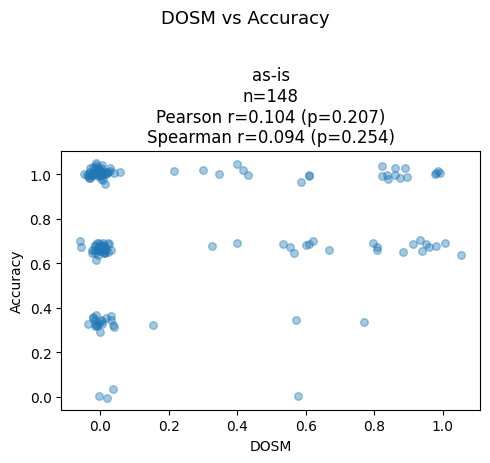

DOSM | as-is: Pearson r=0.104 (p=0.207), Spearman r=0.094 (p=0.254), n=148



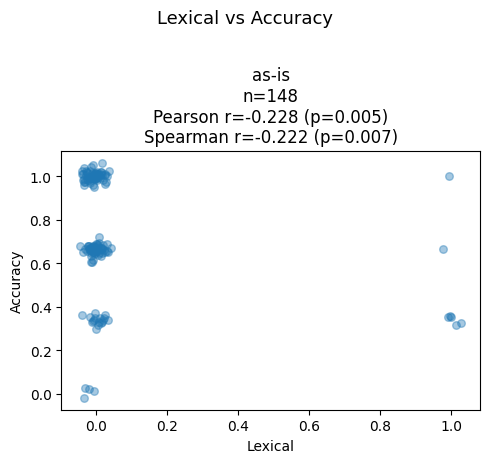

Lexical | as-is: Pearson r=-0.228 (p=0.005), Spearman r=-0.222 (p=0.007), n=148



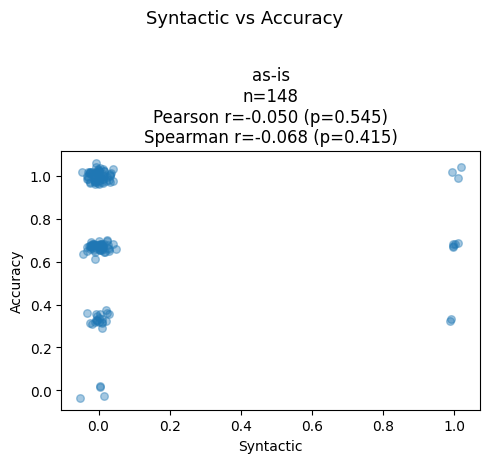

Syntactic | as-is: Pearson r=-0.050 (p=0.545), Spearman r=-0.068 (p=0.415), n=148



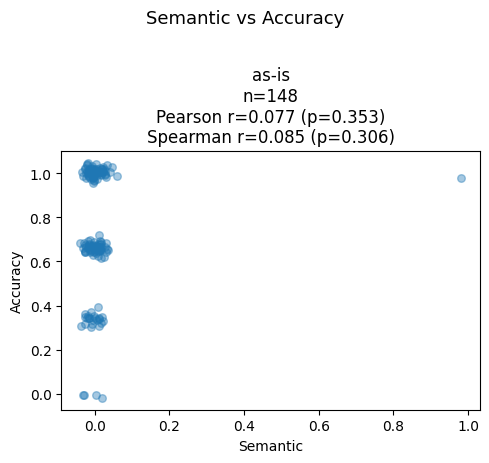

Semantic | as-is: Pearson r=0.077 (p=0.353), Spearman r=0.085 (p=0.306), n=148



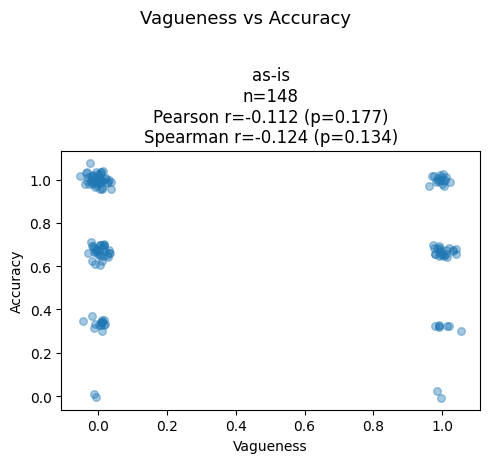

Vagueness | as-is: Pearson r=-0.112 (p=0.177), Spearman r=-0.124 (p=0.134), n=148



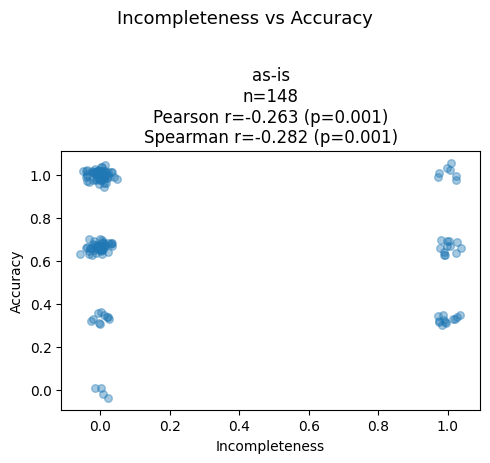

Incompleteness | as-is: Pearson r=-0.263 (p=0.001), Spearman r=-0.282 (p=0.001), n=148



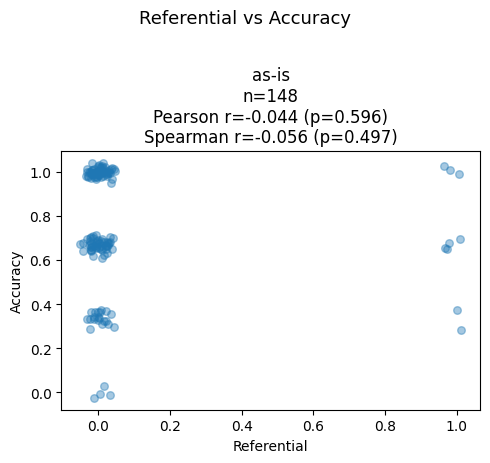

Referential | as-is: Pearson r=-0.044 (p=0.596), Spearman r=-0.056 (p=0.497), n=148



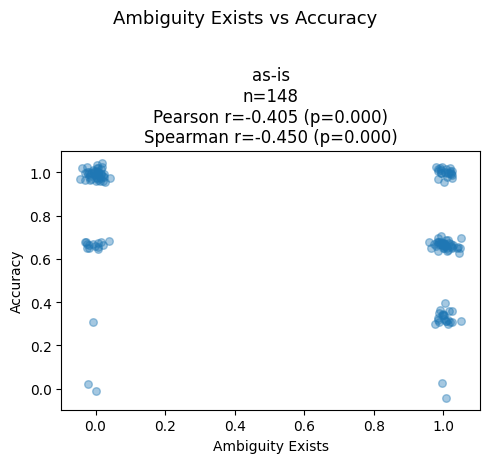

Ambiguity Exists | as-is: Pearson r=-0.405 (p=0.000), Spearman r=-0.450 (p=0.000), n=148



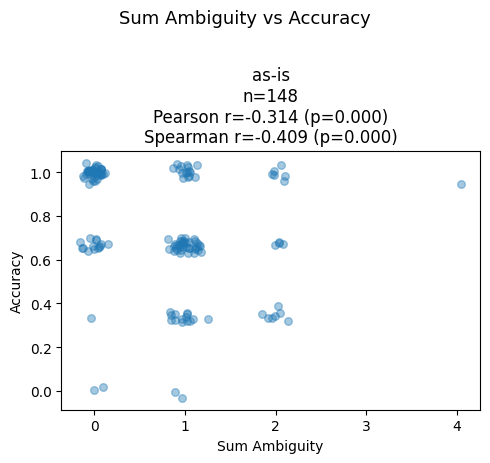

Sum Ambiguity | as-is: Pearson r=-0.314 (p=0.000), Spearman r=-0.409 (p=0.000), n=148



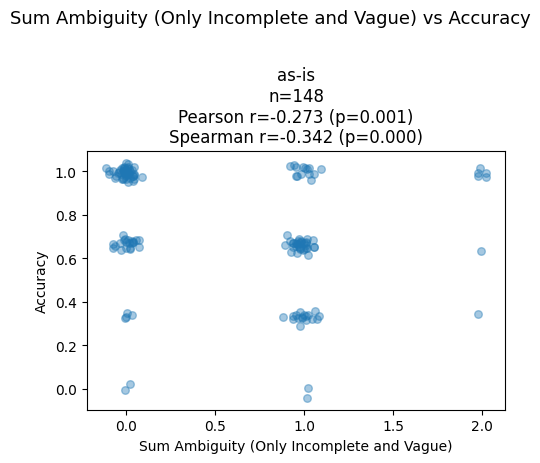

Sum Ambiguity (Only Incomplete and Vague) | as-is: Pearson r=-0.273 (p=0.001), Spearman r=-0.342 (p=0.000), n=148



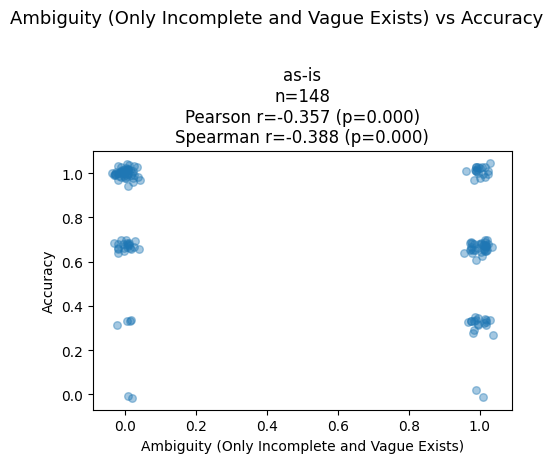

Ambiguity (Only Incomplete and Vague Exists) | as-is: Pearson r=-0.357 (p=0.000), Spearman r=-0.388 (p=0.000), n=148



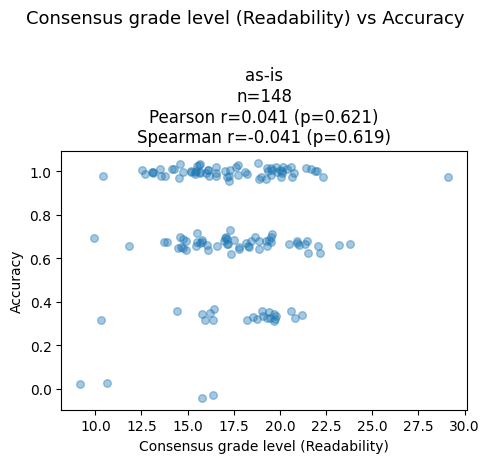

Consensus grade level (Readability) | as-is: Pearson r=0.041 (p=0.621), Spearman r=-0.041 (p=0.619), n=148



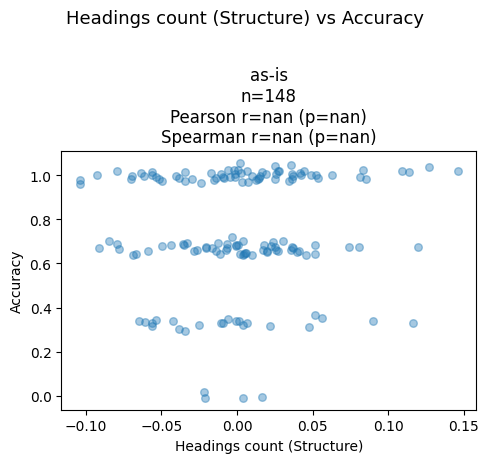

Headings count (Structure) | as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148



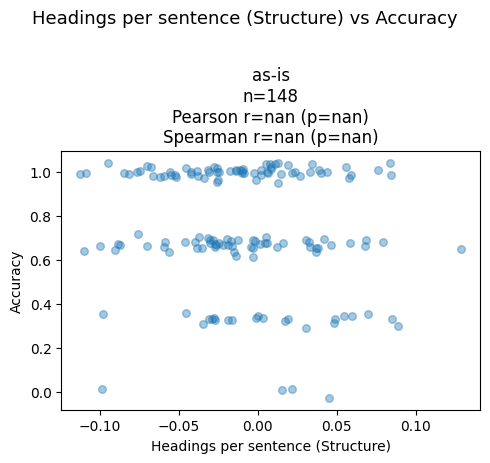

Headings per sentence (Structure) | as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148



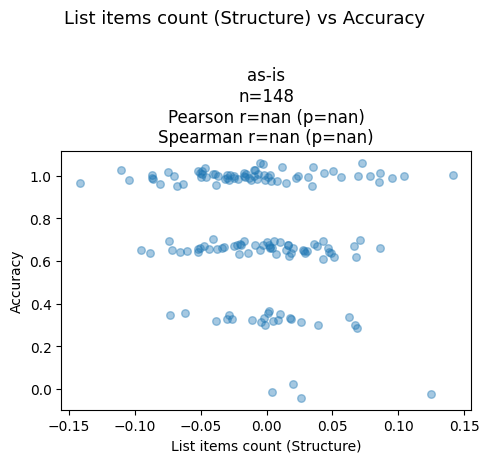

List items count (Structure) | as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148



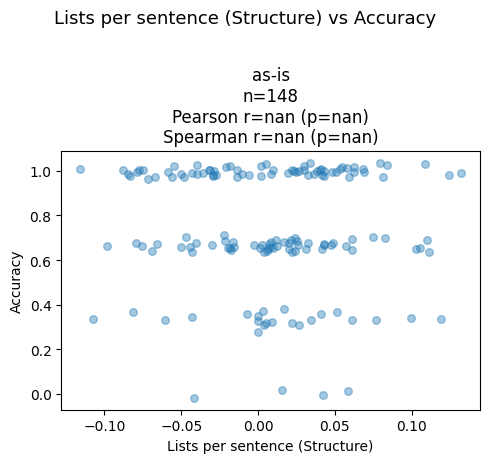

Lists per sentence (Structure) | as-is: Pearson r=nan (p=nan), Spearman r=nan (p=nan), n=148



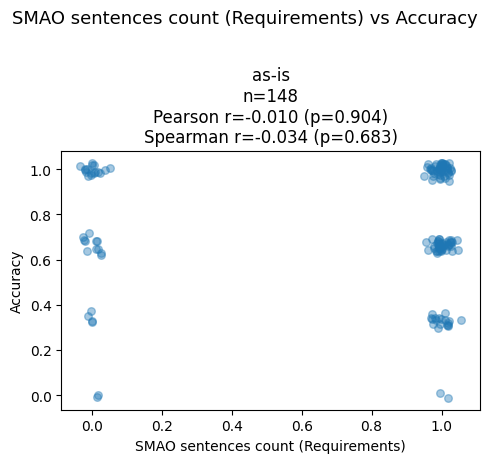

SMAO sentences count (Requirements) | as-is: Pearson r=-0.010 (p=0.904), Spearman r=-0.034 (p=0.683), n=148



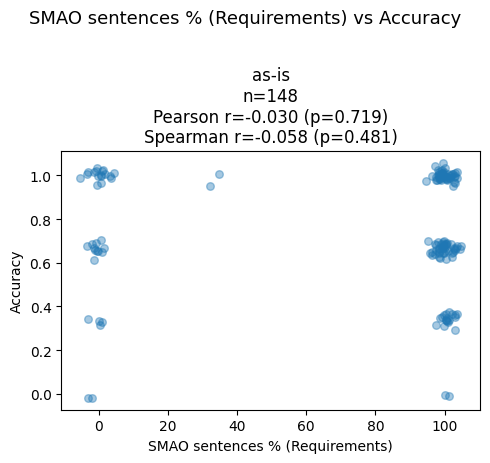

SMAO sentences % (Requirements) | as-is: Pearson r=-0.030 (p=0.719), Spearman r=-0.058 (p=0.481), n=148



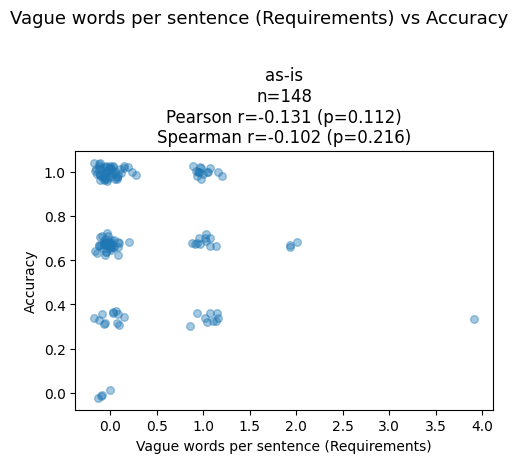

Vague words per sentence (Requirements) | as-is: Pearson r=-0.131 (p=0.112), Spearman r=-0.102 (p=0.216), n=148



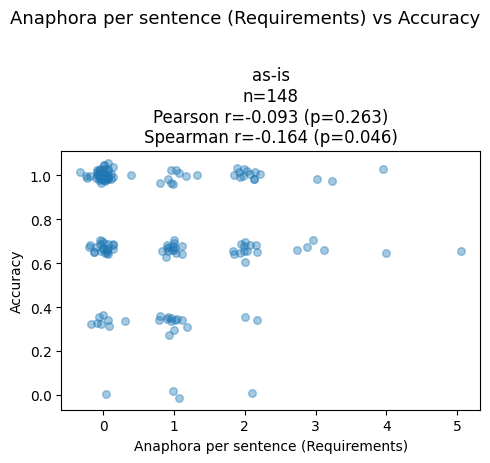

Anaphora per sentence (Requirements) | as-is: Pearson r=-0.093 (p=0.263), Spearman r=-0.164 (p=0.046), n=148



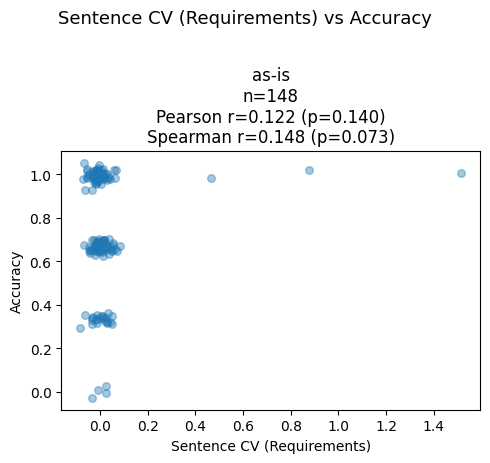

Sentence CV (Requirements) | as-is: Pearson r=0.122 (p=0.140), Spearman r=0.148 (p=0.073), n=148



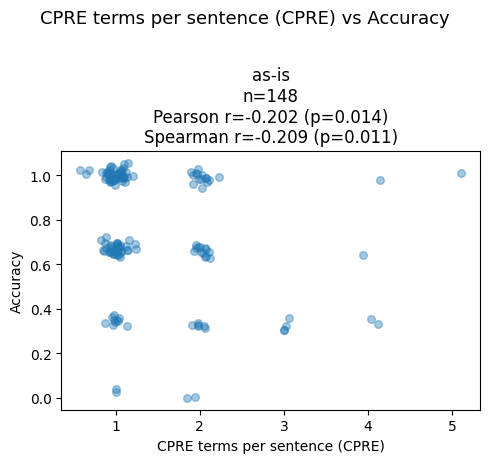

CPRE terms per sentence (CPRE) | as-is: Pearson r=-0.202 (p=0.014), Spearman r=-0.209 (p=0.011), n=148



,metric,mode,n,pearson_r,pearson_p,spearman_r,spearman_p
0,Complexity,as-is,147,-0.018929,8.199904e-01,-0.080437,3.328013e-01
1,LOCC,as-is,148,-0.046917,5.712261e-01,0.007125,9.315055e-01
2,CDC,as-is,148,0.058092,4.831048e-01,0.064247,4.378849e-01
3,CDO,as-is,148,0.066868,4.193869e-01,0.067214,4.169772e-01
4,DOSC,as-is,148,0.057031,4.911413e-01,0.065443,4.293857e-01
5,DOSM,as-is,148,0.104320,2.070215e-01,0.094306,2.542433e-01
6,Lexical,as-is,148,-0.227547,5.413543e-03,-0.221887,6.721203e-03
7,Syntactic,as-is,148,-0.050201,5.445635e-01,-0.067554,4.146162e-01
8,Semantic,as-is,148,0.076907,3.528611e-01,0.084675,3.062057e-01
9,Vagueness,as-is,148,-0.111564,1.770319e-01,-0.123743,1.340298e-01


In [ ]:
original_metrics = [
    'complexity', 'locc', 'cdc', 'cdo', 'docs', 'docm',
    'lexical', 'syntactic', 'semantic', 'vagueness',
    'incompleteness', 'referential', 'ambiguity_exists', 'sum_ambiguity', 'sum_ambiguity_only_incomplete_and_vague', 'ambiguity_only_incomplete_and_vague_exists',
    'value_pct', 'cost_pct', 'risk_pct', 'priority',
]

labels = {
    'complexity': 'Complexity', 'locc': 'LOCC', 'cdc': 'CDC',
    'cdo': 'CDO', 'docs': 'DOSC', 'docm': 'DOSM',
    'lexical': 'Lexical', 'syntactic': 'Syntactic', 'semantic': 'Semantic',
    'vagueness': 'Vagueness', 'incompleteness': 'Incompleteness',
    'referential': 'Referential', 'ambiguity_exists': 'Ambiguity Exists',
    'sum_ambiguity': 'Sum Ambiguity', 'sum_ambiguity_only_incomplete_and_vague': 'Sum Ambiguity (Only Incomplete and Vague)', 'ambiguity_only_incomplete_and_vague_exists': 'Ambiguity (Only Incomplete and Vague Exists)',
    'value_pct': 'Value %', 'cost_pct': 'Cost %', 'risk_pct': 'Risk %', 'priority': 'Priority',
}
for m in complexity2_metric_names:
    labels[m] = m

metrics = original_metrics + complexity2_metric_names

MODE_NAME = 'as-is'

# accuracy distribution
acc = df['accuracy'].dropna()
print(f'=== {MODE_NAME} (n={len(acc)}) ===')
print(acc.value_counts(dropna=False).sort_index().to_string())
print(acc.describe().to_string())
print()


def subset_as_is(df, metric):
    valid = df[[metric, 'accuracy']].dropna()
    if metric == 'complexity':
        valid = valid[valid['complexity'] < 20]
    return valid

def safe_corr(corr_fn, x, y):
    if len(x) < 2 or x.nunique() < 2 or y.nunique() < 2:
        return np.nan, np.nan
    r, p = corr_fn(x.astype(float), y.astype(float))
    return r, p

def fmt_corr(r, p):
    r_str = f'{r:.3f}' if pd.notna(r) else 'nan'
    p_str = f'{p:.3f}' if pd.notna(p) else 'nan'
    return r_str, p_str

np.random.seed(42)
summary_rows = []

for metric in metrics:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    valid = subset_as_is(df, metric)
    pr, pp = safe_corr(pearsonr, valid[metric], valid['accuracy'])
    sr, sp = safe_corr(spearmanr, valid[metric], valid['accuracy'])
    summary_rows.append({
        'metric': labels[metric],
        'mode': MODE_NAME,
        'n': len(valid),
        'pearson_r': pr,
        'pearson_p': pp,
        'spearman_r': sr,
        'spearman_p': sp,
    })

    if len(valid) == 0:
        ax.set_title(f'{MODE_NAME}\nn=0')
        ax.set_xlabel(labels[metric])
    else:
        x_vals = valid[metric].astype(float)
        y_vals = valid['accuracy'].astype(float)
        x_range = x_vals.max() - x_vals.min()
        y_range = y_vals.max() - y_vals.min()
        x_jitter = np.random.normal(0, (x_range * 0.02) if x_range > 0 else 0.05, size=len(valid))
        y_jitter = np.random.normal(0, (y_range * 0.02) if y_range > 0 else 0.02, size=len(valid))

        ax.scatter(
            x_vals + x_jitter,
            y_vals + y_jitter,
            alpha=0.4, s=30,
        )
        pr_str, pp_str = fmt_corr(pr, pp)
        sr_str, sp_str = fmt_corr(sr, sp)
        ax.set_title(
            f'{MODE_NAME}\n'
            f'n={len(valid)}\n'
            f'Pearson r={pr_str} (p={pp_str})\n'
            f'Spearman r={sr_str} (p={sp_str})'
        )
        ax.set_xlabel(labels[metric])

    ax.set_ylabel('Accuracy')
    fig.suptitle(f'{labels[metric]} vs Accuracy', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    pr_str, pp_str = fmt_corr(pr, pp)
    sr_str, sp_str = fmt_corr(sr, sp)
    print(
        f"{labels[metric]} | {MODE_NAME}: "
        f"Pearson r={pr_str} (p={pp_str}), "
        f"Spearman r={sr_str} (p={sp_str}), n={len(valid)}"
    )
    print()

summary = pd.DataFrame(summary_rows)
summary


# Pearson summary table


In [10]:
pearson_wide = summary.pivot(index='metric', columns='mode', values='pearson_r')
pearson_wide.round(3)


mode,as-is
metric,
Ambiguity (Only Incomplete and Vague Exists),-0.357
Ambiguity Exists,-0.405
Anaphora per sentence (Requirements),-0.093
CDC,0.058
CDO,0.067
CPRE terms per sentence (CPRE),-0.202
Complexity,-0.019
Consensus grade level (Readability),0.041
DOSC,0.057


# Spearman summary table


In [11]:
spearman_wide = summary.pivot(index='metric', columns='mode', values='spearman_r')
spearman_wide.round(3)


mode,as-is
metric,
Ambiguity (Only Incomplete and Vague Exists),-0.388
Ambiguity Exists,-0.450
Anaphora per sentence (Requirements),-0.164
CDC,0.064
CDO,0.067
CPRE terms per sentence (CPRE),-0.209
Complexity,-0.080
Consensus grade level (Readability),-0.041
DOSC,0.065


In [ ]:
metric_order = [
    # Ambiguity-related
    'ambiguity_exists', 'sum_ambiguity',
    'lexical', 'syntactic', 'semantic', 'vagueness',
    'incompleteness', 'referential',
    #'sum_ambiguity_only_incomplete_and_vague', 'ambiguity_only_incomplete_and_vague_exists',
    # Code-related
    'locc', 'cdc', 'cdo', 'docs', 'docm',
    # complexity
    'complexity',
    # relevancy
    'value_pct', 'cost_pct', 'risk_pct', 'priority',
]

cols = ["pearson_r", "pearson_p", "spearman_r", "spearman_p"]

asis = summary[summary['mode'] == MODE_NAME].set_index('metric')
ordered_labels = [labels[m] for m in metric_order]
asis.loc[ordered_labels, cols].round(3)


,pearson_r,pearson_p,spearman_r,spearman_p
metric,,,,
Ambiguity Exists,-0.405,0.000,-0.450,0.000
Sum Ambiguity,-0.314,0.000,-0.409,0.000
Lexical,-0.228,0.005,-0.222,0.007
Syntactic,-0.050,0.545,-0.068,0.415
Semantic,0.077,0.353,0.085,0.306
Vagueness,-0.112,0.177,-0.124,0.134
Incompleteness,-0.263,0.001,-0.282,0.001
Referential,-0.044,0.596,-0.056,0.497
LOCC,-0.047,0.571,0.007,0.932


In [15]:
# Show ["pearson_r", "pearson_p", "spearman_r", "spearman_p"] for all metrics, not just a specific metric order or label mapping.

all_metrics_corr = summary.set_index('metric')[["pearson_r", "pearson_p", "spearman_r", "spearman_p"]]
all_metrics_corr.round(3)

,pearson_r,pearson_p,spearman_r,spearman_p
metric,,,,
Complexity,-0.019,0.820,-0.080,0.333
LOCC,-0.047,0.571,0.007,0.932
CDC,0.058,0.483,0.064,0.438
CDO,0.067,0.419,0.067,0.417
DOSC,0.057,0.491,0.065,0.429
DOSM,0.104,0.207,0.094,0.254
Lexical,-0.228,0.005,-0.222,0.007
Syntactic,-0.050,0.545,-0.068,0.415
Semantic,0.077,0.353,0.085,0.306


In [18]:
# Filter and print metrics with either pearson_p or spearman_p less than 0.05
significant = all_metrics_corr[(all_metrics_corr['pearson_p'] < 0.06) | (all_metrics_corr['spearman_p'] < 0.06)]
significant.round(3)

,pearson_r,pearson_p,spearman_r,spearman_p
metric,,,,
Lexical,-0.228,0.005,-0.222,0.007
Incompleteness,-0.263,0.001,-0.282,0.001
Ambiguity Exists,-0.405,0.000,-0.450,0.000
Sum Ambiguity,-0.314,0.000,-0.409,0.000
Sum Ambiguity (Only Incomplete and Vague),-0.273,0.001,-0.342,0.000
Ambiguity (Only Incomplete and Vague Exists),-0.357,0.000,-0.388,0.000
Anaphora per sentence (Requirements),-0.093,0.263,-0.164,0.046
CPRE terms per sentence (CPRE),-0.202,0.014,-0.209,0.011
